# Create a recommender system for romance readers

In [1]:
import sqlite3
import pandas as pd
import numpy as np

### Load Ratings Data

In [2]:
# open romance.db in sqlite3
conn = sqlite3.connect("byGenre/romance.db")
cursor = conn.cursor()

In [3]:
# key reinforcement
cursor.execute("PRAGMA foreign_keys = ON;")

# speed boost
cursor.execute("PRAGMA journal_mode = WAL;")
cursor.execute("PRAGMA synchronous = OFF;")
cursor.execute("PRAGMA temp_store = FILE;")
cursor.execute("PRAGMA cache_size = -200000;")  # ~200MB RAM

In [4]:
# check ratings table
ratings = pd.read_sql_query(
    "SELECT * FROM ratings",
    conn
)
ratings.head()

,review_id,user_id,book_id,rating
0,d0aa055c0b0a5b0c4f13f9d358d51cd9,8842281e1d1347389f2ab93d60773d4d,18135,4.0
1,11beb5d3be4ebe9983ffa224b968dd17,72fb0d0087d28c832f15776b0d936598,1885,5.0
2,303e3bb8890afde2b3849e9c1ebeaafe,ab2923b738ea3082f5f3efcbbfacb218,47401,4.0
3,fa6ede0afb0a5e0b4d7b78855f81d8ed,ab2923b738ea3082f5f3efcbbfacb218,227443,3.0
4,d6d8cb411ba38957e6c9f0fd80e7617c,ab2923b738ea3082f5f3efcbbfacb218,6185,3.0


## Filter dataset on active users and popular books

The dataset is huge, so to make training iterations tractable on local macihne we filter on:
1. users with >= 15 books rated (75th %ile)
2. books with >= 5 total ratings (between 25th - 50th %ile)

In [5]:
# compute rating counts per user
user_counts = ratings['user_id'].value_counts()

print(user_counts.describe())

count    549278.000000
mean         29.551304
std         106.984293
min           1.000000
25%           2.000000
50%           5.000000
75%          15.000000
max        6390.000000
Name: count, dtype: float64


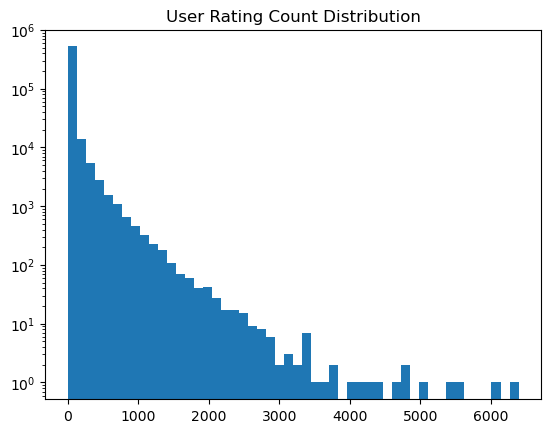

In [8]:
import matplotlib.pyplot as plt

plt.hist(user_counts, bins=50)
plt.yscale("log")
plt.title("User Rating Count Distribution")
plt.show()

In [6]:
# only keep users with >= 15 ratings to manage data size
MIN_RATINGS = 15 #75%ile

active_users = user_counts[user_counts >= MIN_RATINGS].index

ratings_active = ratings[ratings['user_id'].isin(active_users)]

print("Original rows:", len(ratings))
print("Filtered rows:", len(ratings_active))
print("Active users:", ratings_active['user_id'].nunique())

Original rows: 16231881
Filtered rows: 14496446
Active users: 142093


In [7]:
# compute rating counts per book
book_counts = ratings_active['book_id'].value_counts()

book_counts.describe()

count    283631.000000
mean         51.110231
std         349.082097
min           1.000000
25%           3.000000
50%           8.000000
75%          24.000000
max       46027.000000
Name: count, dtype: float64

In [8]:
# only keep books with >= 5 ratings
MIN_COUNTS = 5 #between 25 - 50%ile

popular_books = book_counts[book_counts >= MIN_COUNTS].index

ratings_filtered = ratings_active[
    ratings_active['book_id'].isin(popular_books)
]


print("Original rows:", len(ratings_active))
print("Filtered rows:", len(ratings_filtered))
print("Popular Books:", ratings_filtered['book_id'].nunique())

Original rows: 14496446
Filtered rows: 14273971
Popular Books: 181998


## Prep data for ALS

The goal is to use `implicit` library's implementation of ALS and other recommender algorithms. These are based on ***implicit collaborative filtering***, meaning that any interactions recorded indicate positive feedback. Thus, we filter out negative ratings (1-2) as these can be misinterpreted by the models, and scale the other values to preserve weights of the ratings, i.e. confidence in positive interaction. 

In [9]:
# filter negative ratings (1 & 2)
# scale ratings to confidence in positive interaction for ALS
ratings_pos = ratings_filtered[ratings_filtered['rating'] >= 3]
ratings_pos['confidence'] = ratings_pos['rating'] - 2  # maps 3→1, 4→2, 5→3

print("Original rows:", len(ratings_filtered))
print("Filtered rows:", len(ratings_pos))

Original rows: 14273971
Filtered rows: 13254477


/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/807650794.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_pos['confidence'] = ratings_pos['rating'] - 2  # maps 3→1, 4→2, 5→3


### Encode user and book IDs

In [44]:
# encode user and book ids to integers for conversion to csr
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
book_encoder = LabelEncoder()

ratings_pos['user_idx'] = user_encoder.fit_transform(ratings_pos['user_id'])
ratings_pos['book_idx'] = book_encoder.fit_transform(ratings_pos['book_id'])

/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/2913408694.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_pos['user_idx'] = user_encoder.fit_transform(ratings_pos['user_id'])
/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/2913408694.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ratings_pos['book_idx'] = book_encoder.fit_transform(ratings_pos['book_id'])


### Generate Sparse Matrix

In [45]:
# generate sparse matrix with confidence scores as values
from scipy.sparse import csr_matrix

n_users = ratings_pos['user_idx'].nunique()
n_books = ratings_pos['book_idx'].nunique()

user_item_matrix = csr_matrix(
    (
        ratings_pos['confidence'], # use scaled confidence instead of rating
        (ratings_pos['user_idx'], ratings_pos['book_idx'])
    ),
    shape=(n_users, n_books)
)

In [46]:
print(user_item_matrix)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13254477 stored elements and shape (142078, 181983)>
  Coords	Values
  (0, 30308)	3.0
  (0, 122761)	3.0
  (0, 122763)	2.0
  (0, 122764)	2.0
  (0, 122765)	2.0
  (0, 122766)	2.0
  (0, 122767)	2.0
  (0, 122768)	2.0
  (0, 122769)	2.0
  (0, 122770)	2.0
  (0, 122771)	2.0
  (0, 122772)	2.0
  (0, 122773)	2.0
  (0, 122774)	2.0
  (0, 122775)	2.0
  (0, 122776)	2.0
  (0, 122777)	2.0
  (0, 122778)	2.0
  (0, 122780)	2.0
  (0, 122781)	1.0
  (0, 154514)	2.0
  (1, 1453)	3.0
  (1, 3874)	3.0
  (1, 4602)	2.0
  (1, 6181)	3.0
  :	:
  (142076, 180237)	2.0
  (142076, 180807)	1.0
  (142076, 180936)	3.0
  (142076, 180978)	2.0
  (142076, 181336)	2.0
  (142076, 181605)	3.0
  (142077, 25903)	3.0
  (142077, 48478)	2.0
  (142077, 49530)	2.0
  (142077, 52003)	2.0
  (142077, 56882)	1.0
  (142077, 71181)	3.0
  (142077, 80278)	1.0
  (142077, 95358)	2.0
  (142077, 99991)	3.0
  (142077, 104273)	3.0
  (142077, 116695)	3.0
  (142077, 123289)	3.0
  (142077, 148389

## Model Training/Testing

## Alternating Least Squares - ALS

Matrix factorization: decomposes the user-item interaction matrix into two lower-dimensional matrices — one for users and one for items — such that their product approximates the original. "Alternating" i.e., fixes one matrix and solves for the other, then swaps, iterating until convergence.

I do two different train/test splits:
1. 80/20 train/test split per user (trained on 80% of their interactions)
2. LKO: Leave-k-out (k = 3 = 0.2*15) since 15 is the minimum ratings per user

(2) is harder because a smaller amount of books in the holdout set, no telling if they are closely linked to the training books.

### Option 1: 80/20 interactions split per user

In [13]:
# Option 1: 80/20 interactions split per user
# generate train-test split of csr matrix
from scipy.sparse import lil_matrix

def train_test_split_per_user(csr, test_frac=0.2, random_state=42):
    """
    Hold out a fraction of each user's interactions as the test set.
    Returns two CSR matrices of the same shape.
    """
    rng = np.random.default_rng(random_state)
    
    train = lil_matrix(csr.shape) #ListofLists sparse matrix
    test = lil_matrix(csr.shape)
    
    csr = csr.tocsr()
    
    for user_id in range(csr.shape[0]):
        # Get all items this user interacted with
        item_indices = csr[user_id].indices
        ratings = csr[user_id].data
        
        if len(item_indices) == 0:
            continue
            
        # Need at least 2 interactions to split
        n_test = max(1, int(len(item_indices) * test_frac))
        if len(item_indices) - n_test < 1:
            # Not enough interactions — put everything in train
            # Should not hit this though based on user filtering done earlier
            train[user_id, item_indices] = ratings
            continue
        
        # Randomly select test indices
        test_mask = rng.choice(len(item_indices), size=n_test, replace=False)
        train_mask = np.setdiff1d(np.arange(len(item_indices)), test_mask)

        # Populate train and test
        train[user_id, item_indices[train_mask]] = ratings[train_mask]
        test[user_id, item_indices[test_mask]] = ratings[test_mask]
    
    return train.tocsr(), test.tocsr()


train, test = train_test_split_per_user(user_item_matrix, test_frac=0.2)

In [14]:
train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10659768 stored elements and shape (142078, 181983)>

In [15]:
test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 2594709 stored elements and shape (142078, 181983)>

### Train quick baseline ALS

In [16]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=20
)

model.fit(train)

/opt/anaconda3/envs/goodreads-env/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/20 [00:00<?, ?it/s]

### Evaluation

We use three model evaluations:

1. **precision@k** : how many of the top k recommended items are in test set
2. **recall@k** : how many of the test set are in the top k recommended
3. **NDCG@k** : measures ranking quality by awarding higher scores to relevant items at the top of the list

In our case, we mainly care about precision@k and NDCG@k since a good book recommender shows only a few highly relevant items, and we want the most relevant items first.

There is still nuance in interpretation of these measures since the search space is so big (~180,000 books).

Internal evaluation functions in `implicit` were not working, so we compute explicity. 

We take advantage of parallelization at user level and only generate model recommendations once for all three metrics.

In [16]:
import numpy as np
from joblib import Parallel, delayed

def _evaluate_user(user_id, model, train, test, K):
    """Compute precision, recall and NDCG for a single user."""
    test_items = test[user_id].indices
    if len(test_items) == 0:
        return None
    
    recs = model.recommend(
        user_id,
        train[user_id],
        N=K,
        filter_already_liked_items=True
    )
    rec_items = recs[0]
    test_items_set = set(test_items)
    
    # Precision & Recall
    n_relevant = len(np.intersect1d(rec_items, test_items))
    precision = n_relevant / K
    recall = n_relevant / len(test_items)
    
    # NDCG
    dcg = sum(
        1 / np.log2(rank + 2)
        for rank, item in enumerate(rec_items)
        if item in test_items_set
    )
    ideal_hits = min(len(test_items), K)
    idcg = sum(1 / np.log2(rank + 2) for rank in range(ideal_hits))
    ndcg = dcg / idcg if idcg > 0 else 0
    
    return precision, recall, ndcg


def evaluate_model(model, train, test, K=10, n_jobs=-1):
    """
    Evaluate model across all users in parallel.
    n_jobs=-1 uses all available cores.
    """
    results = Parallel(n_jobs=n_jobs, prefer="threads")(
        delayed(_evaluate_user)(user_id, model, train, test, K)
        for user_id in range(train.shape[0])
    )
    
    # Filter out users with no test interactions
    results = [r for r in results if r is not None]
    precisions, recalls, ndcgs = zip(*results)
    
    return {
        f"precision@{K}": np.mean(precisions),
        f"recall@{K}":    np.mean(recalls),
        f"ndcg@{K}":      np.mean(ndcgs),
    }



In [ ]:
metrics = evaluate_model(model, train, test, K=10, n_jobs = 4)

In [20]:
print(metrics)

{'precision@10': np.float64(0.1792644212156407), 'recall@10': np.float64(0.19450839170858142), 'ndcg@10': np.float64(0.2693991065338656)}


### ALS, 80/20 split:

| Metric | Value |
| --- | --- |
| precision@10 | 0.1792 |
| recall@10 | 0.1945 |
| ndcg@10 | 0.2693 |

precision@k: On average, 1.8 of the top 10 recommendations match one of the 3 specific books held out per user.

recall@k: On average, the model is recovering 20% (i.e., ~1 of the 3) held-out books in the top 10 recommendations.

ndcg@10: Model is putting relevant recommendations higher in the list

### Option 2: LKO Split

In [17]:
# Leave k out - k = 3 here.
from implicit.evaluation import leave_k_out_split

trainK, testK = leave_k_out_split(user_item_matrix, K=3, random_state=42)

In [21]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=50,
    regularization=0.01,
    iterations=20
)

model.fit(trainK)

  0%|          | 0/20 [00:00<?, ?it/s]

In [23]:
metrics = evaluate_model(model, trainK, testK, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.06183917601307557), 'recall@10': np.float64(0.20613058671025192), 'ndcg@10': np.float64(0.1763510477785371)}


### ALS, LKO split:

| Metric | Value |
| --- | --- |
| precision@10 | 0.0618 |
| recall@10 | 0.2061 |
| ndcg@10 | 0.1763 |

This is the harder evaluation case, however it more closely mirrors real-world performance. 

How to interpret:

precision@k: On average, 0.6 of the top 10 recommendations match one of the 3 specific books held out per user.

recall@k: On average, the model is recovering 20% (i.e., ~1 of the 3) held-out books in the top 10 recommendations.

Compated to naive baseline (random recommendations from 180,000 books):

- for this LKO, K = 3: Random Precision@10 = 3 / 180,000 ≈ 0.0017%
- model at 6.22% is **~3,700x better than random**

## Try increasing factors and iterations 

### 80/20 Split

In [18]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=100,
    regularization=0.01,
    iterations=50
)

model.fit(train)

/opt/anaconda3/envs/goodreads-env/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 8 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/50 [00:00<?, ?it/s]

In [19]:
metrics = evaluate_model(model, train, test, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.20254742547425475), 'recall@10': np.float64(0.2121068170302732), 'ndcg@10': np.float64(0.29853882580141927)}


We see some improvement by increasing the factors and iterations:

| model | precision@10 | recall@10 | ndcg@10 |
| --- | --- | --- | --- |
| baseline | 0.178721 | 0.193812 | 0.268730 |
| **increased** | **0.202547** | **0.212106** | **0.298538**|

### LKO Split

In [25]:
from implicit.als import AlternatingLeastSquares

model = AlternatingLeastSquares(
    factors=100,
    regularization=0.01,
    iterations=50
)

model.fit(trainK)

  0%|          | 0/50 [00:00<?, ?it/s]

In [94]:
metrics = evaluate_model(model, trainK, testK, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.07040452572845629), 'recall@10': np.float64(0.23468175242818767), 'ndcg@10': np.float64(0.20063686394981795)}


Again, we see some improvement by increasing the factors and iterations:

| model | precision@10 | recall@10 | ndcg@10 |
| --- | --- | --- | --- |
| baseline | 0.061839 | 0.206130 | 0.176351 |
| **increased** | **0.070404** | **0.234681** | **0.200636**|

### GridSearch to Optimize ALS

In [117]:
from implicit.als import AlternatingLeastSquares
from itertools import product

# Define search grid
factors_grid =         [50, 100, 200]
iterations_grid =      [15, 20, 50]
regularization_grid =  [0.01, 0.1, 1.0]

configs = list(product(factors_grid, iterations_grid, regularization_grid)) # generate grid 
print(f"Total configurations to test: {len(configs)}")

results = []
for factors, iterations, regularization in configs:
    model = AlternatingLeastSquares(
        factors=factors,
        iterations=iterations,
        regularization=regularization,
        random_state=42
    )
    model.fit(train)
    metrics = evaluate_model(model, train, test, K=10, n_jobs = 8)
    metrics.update({
        'factors': factors,
        'iterations': iterations,
        'regularization': regularization
    })
    results.append(metrics)
    print(f"factors={factors}, iterations={iterations}, reg={regularization} | {metrics}")

results_df = pd.DataFrame(results)
print("\nTop 10 configurations by NDCG@10:")
print(results_df.sort_values('ndcg@10', ascending=False).head(10).to_string())

print("\nTop 10 configurations by P@10:")
print(results_df.sort_values('precision@10', ascending=False).head(10).to_string())

Total configurations to test: 27


  0%|          | 0/15 [00:00<?, ?it/s]

factors=50, iterations=15, reg=0.01 | {'precision@10': np.float64(0.17875197972758947), 'recall@10': np.float64(0.19377300359555366), 'ndcg@10': np.float64(0.2686674934393524), 'factors': 50, 'iterations': 15, 'regularization': 0.01}


  0%|          | 0/15 [00:00<?, ?it/s]

factors=50, iterations=15, reg=0.1 | {'precision@10': np.float64(0.17876183437159046), 'recall@10': np.float64(0.19377455594843637), 'ndcg@10': np.float64(0.2686883513901382), 'factors': 50, 'iterations': 15, 'regularization': 0.1}


...

factors=200, iterations=50, reg=0.01 | {'precision@10': np.float64(0.2215288776264386), 'recall@10': np.float64(0.22295254045094842), 'ndcg@10': np.float64(0.3206420646470024), 'factors': 200, 'iterations': 50, 'regularization': 0.01}


  0%|          | 0/50 [00:00<?, ?it/s]

factors=200, iterations=50, reg=0.1 | {'precision@10': np.float64(0.22149579417872103), 'recall@10': np.float64(0.22293378486332716), 'ndcg@10': np.float64(0.3206244374243958), 'factors': 200, 'iterations': 50, 'regularization': 0.1}


  0%|          | 0/50 [00:00<?, ?it/s]

factors=200, iterations=50, reg=1.0 | {'precision@10': np.float64(0.22148805124414878), 'recall@10': np.float64(0.22286475440463274), 'ndcg@10': np.float64(0.32060046373870316), 'factors': 200, 'iterations': 50, 'regularization': 1.0}

Top 10 configurations by NDCG@10:
    precision@10  recall@10   ndcg@10  factors  iterations  regularization
18      0.222071   0.223596  0.321662      200          15            0.01
19      0.222036   0.223505  0.321574      200          15            0.10
20      0.221858   0.223234  0.321330      200          15            1.00
21      0.221785   0.223189  0.321069      200          20            0.01
22      0.221707   0.223106  0.320992      200          20            0.10
23      0.221588   0.222902  0.320835      200          20            1.00
24      0.221529   0.222953  0.320642      200          50            0.01
25      0.221496   0.222934  0.320624      200          50            0.10
26      0.221488   0.222865  0.320600      200         

***Best Configs for ALS***: 200 factors, 15 iterations, 0.01 regularization

## Bayesian Personalized Ranking

Pairwise ranking objective (liked > not liked) using stochastic gradient descent (sampling tripes of [user, liked, not liked]). 

Start small with 50 factors and 20 iterations

### 80/20 Split

In [20]:
from implicit.cpu.bpr import BayesianPersonalizedRanking

model = BayesianPersonalizedRanking(
    factors=50,
    regularization=0.01,
    iterations=20
)

model.fit(train)

  0%|          | 0/20 [00:00<?, ?it/s]

In [21]:
metrics = evaluate_model(model, train, test, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.07485939534720024), 'recall@10': np.float64(0.08715836550930486), 'ndcg@10': np.float64(0.11034397587162754)}


Baseline ALS outperforms baseline BPR:

| model | precision@10 | recall@10 | ndcg@10 |
| --- | --- | --- | --- |
| **ALS** | **0.178721** | **0.193812** | **0.268730** |
| BPR | 0.074859 | 0.087158 | 0.110343 |

### LKO Split

In [22]:
from implicit.cpu.bpr import BayesianPersonalizedRanking

model = BayesianPersonalizedRanking(
    factors=50,
    regularization=0.01,
    iterations=20
)

model.fit(trainK)

  0%|          | 0/20 [00:00<?, ?it/s]

In [23]:
metrics = evaluate_model(model, trainK, testK, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.03209998309192357), 'recall@10': np.float64(0.10699994363974524), 'ndcg@10': np.float64(0.08660198240773988)}


Again, ALS beats BPR in LKO split:

| model | precision@10 | recall@10 | ndcg@10 |
| --- | --- | --- | --- |
| **ALS** | **0.061839** | **0.206130** | **0.176351** |
| BPR | 0.032099 | 0.106999 | 0.086601 |

## Try increasing factors and iterations

### 80/20

In [24]:
from implicit.cpu.bpr import BayesianPersonalizedRanking

model = BayesianPersonalizedRanking(
    factors=100,
    regularization=0.01,
    iterations=50
)

model.fit(train)

  0%|          | 0/50 [00:00<?, ?it/s]

In [25]:
metrics = evaluate_model(model, train, test, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.08425368669271108), 'recall@10': np.float64(0.1077256574945524), 'ndcg@10': np.float64(0.1298913939436684)}


### Leave-k-out

In [26]:
from implicit.cpu.bpr import BayesianPersonalizedRanking

model = BayesianPersonalizedRanking(
    factors=100,
    regularization=0.01,
    iterations=50
)

model.fit(trainK)

  0%|          | 0/50 [00:00<?, ?it/s]

In [27]:
metrics = evaluate_model(model, trainK, testK, K=10, n_jobs = 4)
print(metrics)

{'precision@10': np.float64(0.03783745702530575), 'recall@10': np.float64(0.1261248567510192), 'ndcg@10': np.float64(0.10313280182045284)}


## Model is likely undertraining - BPR needs lots of iterations

In [ ]:
from implicit.bpr import BayesianPersonalizedRanking

bpr_model = BayesianPersonalizedRanking(
    factors=50,
    iterations=1000,
    learning_rate=0.01,
    regularization=0.01,
    random_state=42
)
bpr_model.fit(train)

In [114]:
metrics = evaluate_model(model, train, test, K=10, n_jobs = 8)
print(metrics)

{'precision@10': np.float64(0.003975644951254707), 'recall@10': np.float64(0.01265909804390827), 'ndcg@10': np.float64(0.01106505401729926)}


In [115]:
# Grid search key BPR hyperparameters
configs = [
    {'factors': 50,  'iterations': 500,  'learning_rate': 0.01},
    {'factors': 50,  'iterations': 1000, 'learning_rate': 0.01},
    {'factors': 100, 'iterations': 500,  'learning_rate': 0.05},
    {'factors': 100, 'iterations': 1000, 'learning_rate': 0.05},
]

for config in configs:
    bpr = BayesianPersonalizedRanking(**config, random_state=42)
    bpr.fit(train)
    metrics = evaluate_model(bpr, train, test, K=10, n_jobs = 8)
    print(f"{config} -> {metrics}")

  0%|          | 0/500 [00:00<?, ?it/s]

{'factors': 50, 'iterations': 500, 'learning_rate': 0.01} -> {'precision@10': np.float64(0.09268715024812586), 'recall@10': np.float64(0.12663838309762002), 'ndcg@10': np.float64(0.14341955220751132)}


  0%|          | 0/1000 [00:00<?, ?it/s]

{'factors': 50, 'iterations': 1000, 'learning_rate': 0.01} -> {'precision@10': np.float64(0.09598704818217013), 'recall@10': np.float64(0.13325342998266304), 'ndcg@10': np.float64(0.1497418148753548)}


  0%|          | 0/500 [00:00<?, ?it/s]

{'factors': 100, 'iterations': 500, 'learning_rate': 0.05} -> {'precision@10': np.float64(0.10802871924823142), 'recall@10': np.float64(0.14731628567454602), 'ndcg@10': np.float64(0.166548290411632)}


  0%|          | 0/1000 [00:00<?, ?it/s]

{'factors': 100, 'iterations': 1000, 'learning_rate': 0.05} -> {'precision@10': np.float64(0.10715517544785838), 'recall@10': np.float64(0.1460784482609892), 'ndcg@10': np.float64(0.16478918699262365)}


In [116]:
# Grid search key BPR hyperparameters
configs = [
    {'factors': 50,  'iterations': 500,  'learning_rate': 0.01},
    {'factors': 50,  'iterations': 1000, 'learning_rate': 0.01},
    {'factors': 100, 'iterations': 500,  'learning_rate': 0.05},
    {'factors': 100, 'iterations': 1000, 'learning_rate': 0.05},
]

for config in configs:
    bpr = BayesianPersonalizedRanking(**config, random_state=42)
    bpr.fit(trainK)
    metrics = evaluate_model(bpr, trainK, testK, K=10, n_jobs = 8)
    print(f"{config} -> {metrics}")

  0%|          | 0/500 [00:00<?, ?it/s]

{'factors': 50, 'iterations': 500, 'learning_rate': 0.01} -> {'precision@10': np.float64(0.04233148283830243), 'recall@10': np.float64(0.14110494279434146), 'ndcg@10': np.float64(0.11419886071244983)}


  0%|          | 0/1000 [00:00<?, ?it/s]

{'factors': 50, 'iterations': 1000, 'learning_rate': 0.01} -> {'precision@10': np.float64(0.04328678915628699), 'recall@10': np.float64(0.14428929718762326), 'ndcg@10': np.float64(0.11584350602668061)}


  0%|          | 0/500 [00:00<?, ?it/s]

{'factors': 100, 'iterations': 500, 'learning_rate': 0.05} -> {'precision@10': np.float64(0.047808995096657834), 'recall@10': np.float64(0.15936331698885942), 'ndcg@10': np.float64(0.12698876648802332)}


  0%|          | 0/1000 [00:00<?, ?it/s]

{'factors': 100, 'iterations': 1000, 'learning_rate': 0.05} -> {'precision@10': np.float64(0.04753846587386574), 'recall@10': np.float64(0.15846155291288586), 'ndcg@10': np.float64(0.12584333204244075)}


BPR is still underperforming ALS by quite a bit.

Train AUC is high (>97%) but test performance is lower than ALS baselines, suggesting overfitting. 

# Incorporating Book-Book Similarity Information

Goodreads provides lists of similar books for each book. We will use these to create a book-book similarity matrix to add a small weight to books known to be similar to each users liked books in hopes it increases model performance.

In [28]:
# Load from SQL
books = pd.read_sql_query(
    "SELECT * FROM similar_books",
    conn
)

books.head()

,book_id,similar_book_id
0,29074693,25515353
1,29074693,20483269
2,29074693,25650829
3,29074693,18913492
4,29074693,22578299


In [33]:
# We keep only books that exist in our filtered user-item matrix (ratings_pos)
unique_books = ratings_pos['book_id'].unique()

mask = books['book_id'].isin(unique_books)
books_filtered = books[mask]

mask_2 = books_filtered['similar_book_id'].isin(unique_books)
books_filt = books_filtered[mask_2]

In [35]:
books_filt.shape

(1662509, 2)

In [37]:
# use the encodings from earlier to match books to user_item_matrix
books_filt['book_idx'] = book_encoder.transform(books_filt['book_id'])
books_filt['sim_book_idx'] = book_encoder.transform(books_filt['similar_book_id'])

/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/2703192558.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_filt['book_idx'] = book_encoder.transform(books_filt['book_id'])
/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/2703192558.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_filt['sim_book_idx'] = book_encoder.transform(books_filt['similar_book_id'])


In [38]:
books_filt.head()

,book_id,similar_book_id,book_idx,sim_book_idx
0,29074693,25515353,124077,104512
2,29074693,25650829,124077,106061
3,29074693,18913492,124077,60510
4,29074693,22578299,124077,79764
5,29074693,25781561,124077,107607


In [52]:
# crease book_similarity_matrix sparse matrix - each value is just 1
n_books = len(book_encoder.classes_)

book_similarity_matrix = csr_matrix(
    (np.ones(len(books_filt), dtype=np.float32),
    (books_filt['book_idx'], books_filt['sim_book_idx'])),
    shape=(n_books, n_books)
)

# since similarity was loaded into the table unidirectionally, we make them bidirectional
book_similarity_matrix = book_similarity_matrix + book_similarity_matrix.T
# adjust for possible double counting 
book_similarity_matrix.data[book_similarity_matrix.data > 1] = 1

## Integrate the book-similarity matrix into training data

We create `augmented_train` matrix by adding book_similarity signal to the ***training*** data (Very important! If you augment before splitting, you risk leaking similarity-propagated signal into the training set that originates from test interactions, i.e. data leakage). 

Formula: `train + alpha * (train @ book_similarity_matrix)`

`(train @ book_similarity_matrix)`: matrix multiplication of `train` and `book_similarity_matrix`

i.e., if `train` is shape users x b2 and `book_similarity_matrix` is shape b1 x b2, then for each book b2, sum up the user's ratings for all books that are similar to b2

`alpha` : weighting parameter that scales the book-book similarity

Intuitive example:

Say a user rated 3 books:

| book | rating |
| --- | --- |
| The Hobbit | 5|
| LOTR | 4 |
| Harry Potter | 3 |

And the similarity matrix tells us that *The Name of the Wind* is similar to both The Hobbit and LOTR. Then:

    propagated score for "Name of the Wind" = 5*1 + 4*1 + 3*0 = 9
    augmented score                          = 0 + 0.5 * 9 = 4.5
    
The user has never rated *The Name of the Wind*, but after augmentation it has a score of 4.5 — making it likely to be surfaced by ALS as a recommendation.

In [67]:
alphas = [0, 0.01] # testing various levels of alpha 
results = []

for alpha in alphas:
    # Augment train
    augmented_train = (train + alpha * (train @ book_similarity_matrix)).tocsr()
    
    # Fit model
    model = AlternatingLeastSquares(factors=50, regularization=0.01, iterations=20, random_state=42)
    model.fit(augmented_train)
    
    # Evaluate
    metrics = evaluate_model(model, augmented_train, test, K=10, n_jobs = 4)
    metrics['alpha'] = alpha
    results.append(metrics)
    print(f"alpha={alpha:.2f} | {metrics}")

  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.00 | {'precision@10': np.float64(0.17872171189244368), 'recall@10': np.float64(0.19381266211193085), 'ndcg@10': np.float64(0.26873095558515514), 'alpha': 0}


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.01 | {'precision@10': np.float64(0.09867243867243869), 'recall@10': np.float64(0.13590007809151983), 'ndcg@10': np.float64(0.16555782166969402), 'alpha': 0.01}


In [43]:
alphas = [0.1, 0.2, 0.3, 0.5] # testing various levels of alpha 
results = []

for alpha in alphas:
    # Augment train
    augmented_train = (train + alpha * (train @ book_similarity_matrix)).tocsr()
    
    # Fit model
    model = AlternatingLeastSquares(factors=50, regularization=0.01, iterations=20, random_state=42)
    model.fit(augmented_train)
    
    # Evaluate
    metrics = evaluate_model(model, augmented_train, test, K=10, n_jobs = 4)
    metrics['alpha'] = alpha
    results.append(metrics)
    print(f"alpha={alpha:.2f} | {metrics}")

results_df = pd.DataFrame(results)
print(results_df)

  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.10 | {'precision@10': np.float64(0.06572554816457254), 'recall@10': np.float64(0.10146504580679576), 'ndcg@10': np.float64(0.11852834160068892), 'alpha': 0.1}


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.20 | {'precision@10': np.float64(0.05058951888220182), 'recall@10': np.float64(0.08006421098377721), 'ndcg@10': np.float64(0.09326195040981235), 'alpha': 0.2}


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.30 | {'precision@10': np.float64(0.04295076197515223), 'recall@10': np.float64(0.0687215899513075), 'ndcg@10': np.float64(0.07870054328729607), 'alpha': 0.3}


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.50 | {'precision@10': np.float64(0.03429768063914405), 'recall@10': np.float64(0.055146059119777664), 'ndcg@10': np.float64(0.06023617601827491), 'alpha': 0.5}
   precision@10  recall@10   ndcg@10  alpha
0      0.065726   0.101465  0.118528    0.1
1      0.050590   0.080064  0.093262    0.2
2      0.042951   0.068722  0.078701    0.3
3      0.034298   0.055146  0.060236    0.5


## Adding Book Similarity info *reduces* performance..? 

### Density Check on book_similarity_matrix and augmented_train

The performance of the model degrades as alpha increases, and the iteration time also explodes with `augmented_train`. This is likely because the matrix is too dense, thus it is adding too much noise. 

Let's check:

In [68]:
avg_neighbours = book_similarity_matrix.nnz / book_similarity_matrix.shape[0]
print(f"Average similar books per book: {avg_neighbours:.1f}")
print(f"Matrix density: {book_similarity_matrix.nnz / (book_similarity_matrix.shape[0]**2):.4%}")

Average similar books per book: 16.8
Matrix density: 0.0092%


In [69]:
print(f"train nnz:           {train.nnz:,}")
augmented = train + 0.01 * (train @ book_similarity_matrix)
print(f"augmented_train nnz: {augmented.nnz:,}")

train nnz:           10,659,768
augmented_train nnz: 216,057,625


### Yikes!

Even though the density of similar books is small, the `augmented_train` matrix contains 20x more values than the original training data. This is because some users have rated a large number of books, so it really explodes.

To handle this, we will limit the book_similarty inclusion in two ways:
1. use only the top 5 similar books per book (new table `similar_books_5nn` in db created below for this)
2. only include similar books to books users rated 5 stars (i.e. confidence = 3 in `train`)

This way we limit to the most relevant information

## Re-Do with Top 5 NN Book Similarity

In [88]:
# Load from SQL
books = pd.read_sql_query(
    "SELECT * FROM similar_books_5nn",
    conn
)

books.head()

,book_id,similar_book_id
0,29074693,25515353
1,29074693,20483269
2,29074693,25650829
3,29074693,18913492
4,29074693,22578299


In [89]:
unique_books = ratings_pos['book_id'].unique()

mask = books['book_id'].isin(unique_books)
books_filtered = books[mask]

mask_2 = books_filtered['similar_book_id'].isin(unique_books)
books_filt = books_filtered[mask_2]
books_filt.shape

(554300, 2)

In [90]:
554300/1662509

0.33341172889891124

using top 5 NN, the filtered book-book similarity matrix is 1/3 the size of the original 

In [91]:
# use the encodings from earlier to match books to user_item_matrix
books_filt['book_idx'] = book_encoder.transform(books_filt['book_id'])
books_filt['sim_book_idx'] = book_encoder.transform(books_filt['similar_book_id'])

/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/1152000303.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_filt['book_idx'] = book_encoder.transform(books_filt['book_id'])
/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/1152000303.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_filt['sim_book_idx'] = book_encoder.transform(books_filt['similar_book_id'])


In [93]:
n_books = len(book_encoder.classes_)

book_similarity_matrix = csr_matrix(
    (np.ones(len(books_filt), dtype=np.float32),
    (books_filt['book_idx'], books_filt['sim_book_idx'])),
    shape=(n_books, n_books)
)

book_similarity_matrix = book_similarity_matrix + book_similarity_matrix.T
book_similarity_matrix.data[book_similarity_matrix.data > 1] = 1

In [96]:
def augment_train(train, book_similarity_matrix, alpha=0.1, min_confidence=3.0):
    """
    Only propagate interactions above min_confidence threshold
    to limit explosion of non-zero entries.
    """
    # Keep only strong interactions for propagation
    strong_interactions = train.copy()
    strong_interactions.data[strong_interactions.data < min_confidence] = 0
    strong_interactions.eliminate_zeros()
    
    augmented = train + alpha * (strong_interactions @ book_similarity_matrix)
    augmented = augmented.tocsr()

    print(f"Book similarity nnz:               {book_similarity_matrix.nnz:,} "
          f"(avg {book_similarity_matrix.nnz/book_similarity_matrix.shape[0]:.1f} neighbours/book)")
    print(f"Strong interactions nnz:           {strong_interactions.nnz:,} "
          f"({strong_interactions.nnz/train.nnz:.1%} of total)")
    print(f"Original train nnz:                {train.nnz:,}")
    print(f"Augmented train nnz:               {augmented.nnz:,} "
          f"({augmented.nnz/train.nnz:.1f}x original)")
    
    return augmented

augmented_train = augment_train(train, book_similarity_matrix, alpha=0.1, min_confidence=3.0)

Interactions used for propagation: 3,980,849 (37.3% of total)
Book similarity nnz:               1,038,636 (avg 5.7 neighbours/book)
Strong interactions nnz:           3,980,849 (37.3% of total)
Original train nnz:                10,659,768
Augmented train nnz:               48,128,401 (4.5x original)


## Re-do with Top 3 NN

Top 5 NN augmented matrix still rather dense

In [99]:
# Load from SQL
books = pd.read_sql_query(
    "SELECT * FROM similar_books_3nn",
    conn
)

books.head()

,book_id,similar_book_id
0,29074693,25515353
1,29074693,20483269
2,29074693,25650829
3,3209316,31242
4,3209316,374380


In [100]:
unique_books = ratings_pos['book_id'].unique()

mask = books['book_id'].isin(unique_books)
books_filtered = books[mask]

mask_2 = books_filtered['similar_book_id'].isin(unique_books)
books_filt = books_filtered[mask_2]
books_filt.shape

(335394, 2)

In [103]:
books_filt.shape[0]/1662509

0.2017396597552254

using top 3 NN, the filtered book-book similarity matrix is 1/5 the size of the original 

In [104]:
# use the encodings from earlier to match books to user_item_matrix
books_filt['book_idx'] = book_encoder.transform(books_filt['book_id'])
books_filt['sim_book_idx'] = book_encoder.transform(books_filt['similar_book_id'])

/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/1152000303.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_filt['book_idx'] = book_encoder.transform(books_filt['book_id'])
/var/folders/4y/vrkxrp99271f82n1xn5c8cc80000gn/T/ipykernel_87293/1152000303.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  books_filt['sim_book_idx'] = book_encoder.transform(books_filt['similar_book_id'])


In [105]:
n_books = len(book_encoder.classes_)

book_similarity_matrix_3nn = csr_matrix(
    (np.ones(len(books_filt), dtype=np.float32),
    (books_filt['book_idx'], books_filt['sim_book_idx'])),
    shape=(n_books, n_books)
)

book_similarity_matrix_3nn = book_similarity_matrix_3nn + book_similarity_matrix_3nn.T
book_similarity_matrix_3nn.data[book_similarity_matrix_3nn.data > 1] = 1

In [106]:
def augment_train(train, book_similarity_matrix, alpha=0.1, min_confidence=3.0):
    """
    Only propagate interactions above min_confidence threshold
    to limit explosion of non-zero entries.
    """
    # Keep only strong interactions for propagation
    strong_interactions = train.copy()
    strong_interactions.data[strong_interactions.data < min_confidence] = 0
    strong_interactions.eliminate_zeros()
    
    augmented = train + alpha * (strong_interactions @ book_similarity_matrix)
    augmented = augmented.tocsr()

    print(f"Book similarity nnz:               {book_similarity_matrix.nnz:,} "
          f"(avg {book_similarity_matrix.nnz/book_similarity_matrix.shape[0]:.1f} neighbours/book)")
    print(f"Strong interactions nnz:           {strong_interactions.nnz:,} "
          f"({strong_interactions.nnz/train.nnz:.1%} of total)")
    print(f"Original train nnz:                {train.nnz:,}")
    print(f"Augmented train nnz:               {augmented.nnz:,} "
          f"({augmented.nnz/train.nnz:.1f}x original)")
    
    return augmented

augmented_train = augment_train(train, book_similarity_matrix_3nn, alpha=0.1, min_confidence=3.0)

Book similarity nnz:               632,840 (avg 3.5 neighbours/book)
Strong interactions nnz:           3,980,849 (37.3% of total)
Original train nnz:                10,659,768
Augmented train nnz:               35,289,973 (3.3x original)


## Sparsified Book-Book Augmented ALS

### 80/20 Split:

In [107]:
alphas = [0.1, 0.2, 0.3, 0.5] # testing various levels of alpha 
results = []

for alpha in alphas:
    ### 3nn ###
    # Augment train
    augmented_train = augment_train(train, book_similarity_matrix_3nn, alpha=alpha, min_confidence=3.0)
    
    # Fit model
    model = AlternatingLeastSquares(factors=50, regularization=0.01, iterations=20, random_state=42)
    model.fit(augmented_train)
    
    # Evaluate
    metrics = evaluate_model(model, augmented_train, test, K=10, n_jobs = 4)
    metrics['alpha'] = alpha
    metrics['kNN'] = 3
    results.append(metrics)
    print(f"alpha={alpha:.2f} | {metrics}")

    ### 5nn ###
    # Augment train
    augmented_train = augment_train(train, book_similarity_matrix, alpha=alpha, min_confidence=3.0)
    
    # Fit model
    model = AlternatingLeastSquares(factors=50, regularization=0.01, iterations=20, random_state=42)
    model.fit(augmented_train)
    
    # Evaluate
    metrics = evaluate_model(model, augmented_train, test, K=10, n_jobs = 4)
    metrics['alpha'] = alpha
    metrics['kNN'] = 5
    results.append(metrics)
    print(f"alpha={alpha:.2f} | {metrics}")

results_df = pd.DataFrame(results)
print(results_df)

Book similarity nnz:               632,840 (avg 3.5 neighbours/book)
Strong interactions nnz:           3,980,849 (37.3% of total)
Original train nnz:                10,659,768
Augmented train nnz:               35,289,973 (3.3x original)


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.10 | {'precision@10': np.float64(0.1413930243198536), 'recall@10': np.float64(0.16537928120409026), 'ndcg@10': np.float64(0.22017534293640276), 'alpha': 0.1, 'kNN': 3}
Book similarity nnz:               1,038,636 (avg 5.7 neighbours/book)
Strong interactions nnz:           3,980,849 (37.3% of total)
Original train nnz:                10,659,768
Augmented train nnz:               48,128,401 (4.5x original)


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.10 | {'precision@10': np.float64(0.12840178791398305), 'recall@10': np.float64(0.1555036536647007), 'ndcg@10': np.float64(0.20353799553177426), 'alpha': 0.1, 'kNN': 5}
Book similarity nnz:               632,840 (avg 3.5 neighbours/book)
Strong interactions nnz:           3,980,849 (37.3% of total)
Original train nnz:                10,659,768
Augmented train nnz:               35,289,973 (3.3x original)


...

alpha=0.30 | {'precision@10': np.float64(0.09802695949037413), 'recall@10': np.float64(0.12726886696433365), 'ndcg@10': np.float64(0.15904364040522181), 'alpha': 0.3, 'kNN': 5}
Book similarity nnz:               632,840 (avg 3.5 neighbours/book)
Strong interactions nnz:           3,980,849 (37.3% of total)
Original train nnz:                10,659,768
Augmented train nnz:               35,289,973 (3.3x original)


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.50 | {'precision@10': np.float64(0.09770034843205576), 'recall@10': np.float64(0.12574510738306835), 'ndcg@10': np.float64(0.15560988173429863), 'alpha': 0.5, 'kNN': 3}
Book similarity nnz:               1,038,636 (avg 5.7 neighbours/book)
Strong interactions nnz:           3,980,849 (37.3% of total)
Original train nnz:                10,659,768
Augmented train nnz:               48,128,401 (4.5x original)


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.50 | {'precision@10': np.float64(0.07995072677999508), 'recall@10': np.float64(0.1078386627094048), 'ndcg@10': np.float64(0.13046338975680327), 'alpha': 0.5, 'kNN': 5}
   precision@10  recall@10   ndcg@10  alpha  kNN
0      0.141393   0.165379  0.220175    0.1    3
1      0.128402   0.155504  0.203538    0.1    5
2      0.125912   0.151371  0.197943    0.2    3
3      0.109814   0.138244  0.176912    0.2    5
4      0.114930   0.141787  0.181614    0.3    3
5      0.098027   0.127269  0.159044    0.3    5
6      0.097700   0.125745  0.155610    0.5    3
7      0.079951   0.107839  0.130463    0.5    5


Baseline performance without agumentation for ALS 80/20 was:

| precision@10 | recall@10 | ndcg@10 |
| --- | --- | --- |
| 0.178721 | 0.193812 | 0.268730 |

Thus, augmenting with book similarity in training is not seen to improve model performance

### LKO Split:

In [110]:
alphas = [0.1, 0.2, 0.3, 0.5] # testing various levels of alpha 
results = []

for alpha in alphas:
    ### 3nn ###
    # Augment train
    augmented_train = augment_train(trainK, book_similarity_matrix_3nn, alpha=alpha, min_confidence=3.0)
    
    # Fit model
    model = AlternatingLeastSquares(factors=50, regularization=0.01, iterations=20, random_state=42)
    model.fit(augmented_train)
    
    # Evaluate
    metrics = evaluate_model(model, augmented_train, testK, K=10, n_jobs = 4)
    metrics['alpha'] = alpha
    metrics['kNN'] = 3
    results.append(metrics)
    print(f"alpha={alpha:.2f} | {metrics}")

    ### 5nn ###
    # Augment train
    augmented_train = augment_train(trainK, book_similarity_matrix, alpha=alpha, min_confidence=3.0)
    
    # Fit model
    model = AlternatingLeastSquares(factors=50, regularization=0.01, iterations=20, random_state=42)
    model.fit(augmented_train)
    
    # Evaluate
    metrics = evaluate_model(model, augmented_train, testK, K=10, n_jobs = 4)
    metrics['alpha'] = alpha
    metrics['kNN'] = 5
    results.append(metrics)
    print(f"alpha={alpha:.2f} | {metrics}")

results_df = pd.DataFrame(results)
print(results_df)

Book similarity nnz:               632,840 (avg 3.5 neighbours/book)
Strong interactions nnz:           4,793,045 (37.4% of total)
Original train nnz:                12,828,645
Augmented train nnz:               41,544,441 (3.2x original)


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.10 | {'precision@10': np.float64(0.05174787240038325), 'recall@10': np.float64(0.1724929080012775), 'ndcg@10': np.float64(0.14656661021544884), 'alpha': 0.1, 'kNN': 3}
Book similarity nnz:               1,038,636 (avg 5.7 neighbours/book)
Strong interactions nnz:           4,793,045 (37.4% of total)
Original train nnz:                12,828,645
Augmented train nnz:               56,262,084 (4.4x original)


  0%|          | 0/20 [00:00<?, ?it/s]

alpha=0.10 | {'precision@10': np.float64(0.048426844389336636), 'recall@10': np.float64(0.16142281463112212), 'ndcg@10': np.float64(0.13704044230531473), 'alpha': 0.1, 'kNN': 5}
Book similarity nnz:               632,840 (avg 3.5 neighbours/book)
Strong interactions nnz:           4,793,045 (37.4% of total)
Original train nnz:                12,828,645
Augmented train nnz:               41,544,441 (3.2x original)


  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

Baseline performance without agumentation for ALS LKO was:

| precision@10 | recall@10 | ndcg@10 |
| --- | --- | --- |
| 0.0618 | 0.2061 | 0.1763 |

Thus, augmenting with book similarity in training does not help here either (stopped early).

Even when reducing to the "most relevant" similar books in these ways, we still have reduced performance over using just the user-item matrix, i.e. the ***implicit collborative filtering***. 

This could be because we do not know exactly how these similar book lists were generated since they were scraped from goodreads. 

Matrix factorization learns latent item factors that already encode similarity between books. Explicitly injecting similarity on top of this can interfere with the factorization rather than help it.

Next steps:
1. try to use book similarity for post-hoc re-ranking of recommendations from ALS - this way ALS still learns the implicit patterns but we can perhaps improve the order with which they're shown.
2. instead of using book-book similarity from goodreads, generate my own based on other book features I have (e.g., description, authors, shelves/tags).

## Create similar_books_5nn table in db

Unsure how to calculate "top" n neighbors in original book_similarity matrix because there is no information about similarity strength, just binary edges between books. Going back to the original data, similar books are listed for each book. We assume that info from Goodreads has books ranked from most similar to least similar - this way we limit to the first 5 listed books, rather than randomly choosing 5.

In [84]:
# create similar_books_5nn table 
# assumes similar books are listed in rank order
# keeps only top 5
cursor.execute(f"DROP TABLE IF EXISTS similar_books_5nn;")
cursor.execute("""
CREATE TABLE similar_books_5nn (
    book_id TEXT NOT NULL,
    similar_book_id TEXT NOT NULL,
    PRIMARY KEY (book_id, similar_book_id),
    FOREIGN KEY (book_id) REFERENCES books(book_id)
)
""")

import os
from tqdm import tqdm
import gzip
import json

# Functions for loading books info into the database 
def load_json_books(path):
    with gzip.open(path, "rt") as f:
        for i, line in enumerate(tqdm(f)):
            book = json.loads(line)

            for similar_book in book['similar_books'][:5]: # only top 5 similar books
                cursor.execute("""
                    INSERT OR IGNORE INTO similar_books_5nn (
                    book_id, similar_book_id
                    )
                    VALUES (?, ?)
                """, (
                    book["book_id"],
                    similar_book
                ))

                
            if i % 5000 == 0 and i > 0:
                conn.commit()
    conn.commit()

In [85]:
# load book data
DIR_GENRE = './byGenre/'
load_json_books(os.path.join(DIR_GENRE, "goodreads_books_romance.json.gz"))

335449it [00:30, 11076.70it/s]


### Same for Top 3 NN

In [97]:
# create similar_books_3nn table 
# assumes similar books are listed in rank order
# keeps only top 3
# cursor.execute(f"DROP TABLE IF EXISTS similar_books_3nn;")
cursor.execute("""
CREATE TABLE similar_books_3nn (
    book_id TEXT NOT NULL,
    similar_book_id TEXT NOT NULL,
    PRIMARY KEY (book_id, similar_book_id),
    FOREIGN KEY (book_id) REFERENCES books(book_id)
)
""")

import os
from tqdm import tqdm
import gzip
import json

# Functions for loading books info into the database 
def load_json_books(path):
    with gzip.open(path, "rt") as f:
        for i, line in enumerate(tqdm(f)):
            book = json.loads(line)

            for similar_book in book['similar_books'][:3]: # only top 3 similar books
                cursor.execute("""
                    INSERT OR IGNORE INTO similar_books_3nn (
                    book_id, similar_book_id
                    )
                    VALUES (?, ?)
                """, (
                    book["book_id"],
                    similar_book
                ))

                
            if i % 5000 == 0 and i > 0:
                conn.commit()
    conn.commit()

In [98]:
# load book data
DIR_GENRE = './byGenre/'
load_json_books(os.path.join(DIR_GENRE, "goodreads_books_romance.json.gz"))

335449it [00:28, 11749.18it/s]


In [54]:
model.item_factors 

array([[-1.7858701e-03, -1.8712551e-04,  1.5109124e-04, ...,
         2.8127262e-03,  2.0821486e-03, -3.2865237e-03],
       [ 2.3299225e-03,  1.0463087e-02,  4.7679655e-03, ...,
         4.5406828e-03,  6.5882173e-03,  1.2763998e-02],
       [ 2.6499613e-03,  3.0595005e-05, -2.2297357e-03, ...,
         1.8959952e-04,  2.9298142e-03, -6.2295108e-04],
       ...,
       [-2.8960099e-03,  2.5646775e-03,  6.8213511e-04, ...,
         6.5055150e-03,  4.0083788e-03, -3.3141957e-03],
       [-2.7072823e-03,  2.6148430e-03,  1.8843908e-02, ...,
        -1.6360818e-03,  4.9299765e-03,  1.4703665e-03],
       [-2.1303656e-02,  5.3226450e-03,  6.0070134e-03, ...,
         3.7360247e-02,  1.9268895e-02, -1.3905366e-02]],
      shape=(181983, 50), dtype=float32)